In [442]:
import pandas as pd 
import numpy as np                                                                                              
import seaborn as sns
import matplotlib.pyplot as plt
# from sklearn.preprocessing import OneHotEncoder

In [443]:
##Basic setting , read data, clean and convert date time
df = pd.read_csv('data.csv', header=1)
df['Date'] = pd.to_datetime(df['Date'])
df = df.dropna()

In [444]:
df = df.sort_values(by=['Individual code', 'Date'])
df

,Year,Date,Month,Day of Week,Individual code,0,1,2,3,4,...,15,16,17,18,19,20,21,22,23,Daily total (Wh/d)
3178,2013,2013-09-06,9,Friday,F2013_10_B,0.0,5.0,3.0,0.0,0.0,...,0.0,0.0,0.0,2.0,0.0,0.0,18.0,44.0,15.0,87.0
3171,2013,2013-09-07,9,Saturday,F2013_10_B,0.0,5.0,9.0,16.0,28.0,...,0.0,0.0,0.0,0.0,5.0,1.0,0.0,0.0,0.0,104.0
3188,2013,2013-09-08,9,Sunday,F2013_10_B,1.0,0.0,0.0,13.0,11.0,...,0.0,1.0,0.0,0.0,0.0,6.0,4.0,0.0,0.0,55.0
3176,2013,2013-09-09,9,Monday,F2013_10_B,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,88.0
3185,2013,2013-09-10,9,Tuesday,F2013_10_B,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,66.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29438,2019,2019-12-09,12,Monday,F2019_9_D,27.0,35.0,31.0,29.0,29.0,...,0.0,0.0,3.0,20.0,0.0,0.0,0.0,0.0,10.0,403.0
29439,2019,2019-12-10,12,Tuesday,F2019_9_D,44.0,36.0,31.0,32.0,33.0,...,12.0,4.0,0.0,0.0,1.0,0.0,0.0,31.0,31.0,398.0
29440,2019,2019-12-11,12,Wednesday,F2019_9_D,24.0,35.0,49.0,29.0,26.0,...,0.0,0.0,37.0,29.0,27.0,26.0,20.0,19.0,101.0,556.0
29441,2019,2019-12-12,12,Thursday,F2019_9_D,54.0,38.0,26.0,27.0,27.0,...,8.0,29.0,34.0,31.0,37.0,28.0,58.0,28.0,0.0,608.0


In [445]:
# Separate dataset by individual and create Lag1_hour difference features
from typing import List

hour_cols = [str(i) for i in range(24)]

# Ensure we work on a copy
df_filtered = df.copy()

# Initialize Lag1_* columns with NaN (explicit creation without values)
for h in hour_cols:
    df_filtered[f"Lag1_{h}"] = np.nan

# Compute differences per individual (no mixing between individuals).
# For hour m>0: Lag1_m = current_hour_m - current_hour_{m-1}
# For hour 0: Lag1_0 = current_hour_0 - previous_day_hour_23 (shifted).

def _compute_lag_diffs(group):
    group = group.sort_values('Date').copy()
    for i, h in enumerate(hour_cols):
        if i > 0:
            prev_col = hour_cols[i-1]
            group[f"Lag1_{h}"] = group[h].astype(float) - group[prev_col].astype(float)
        else:
            # previous day's hour 23 for hour 0
            prev_day_h23 = group[hour_cols[-1]].shift(1)
            group[f"Lag1_{h}"] = group[h].astype(float) - prev_day_h23.astype(float)
    return group

# Apply per-individual and preserve NaNs for the first day of each individual
df_filtered = df_filtered.groupby('Individual code', group_keys=False).apply(_compute_lag_diffs)

# The first day for each individual will have NaNs (no previous day) as required
# Lag1_Total as the sum of absolute values of Lag1_* columns for each row
lag1_hour_cols = [f"Lag1_{h}" for h in hour_cols]
df_filtered['Lag1_Total'] = df_filtered[lag1_hour_cols].abs().sum(axis=1)

df_filtered

C:\Users\Admin\AppData\Local\Temp\ipykernel_42632\2873376981.py:30: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_filtered = df_filtered.groupby('Individual code', group_keys=False).apply(_compute_lag_diffs)


,Year,Date,Month,Day of Week,Individual code,0,1,2,3,4,...,Lag1_15,Lag1_16,Lag1_17,Lag1_18,Lag1_19,Lag1_20,Lag1_21,Lag1_22,Lag1_23,Lag1_Total
3178,2013,2013-09-06,9,Friday,F2013_10_B,0.0,5.0,3.0,0.0,0.0,...,0.0,0.0,0.0,2.0,-2.0,0.0,18.0,26.0,-29.0,87.0
3171,2013,2013-09-07,9,Saturday,F2013_10_B,0.0,5.0,9.0,16.0,28.0,...,0.0,0.0,0.0,0.0,5.0,-4.0,-1.0,0.0,0.0,97.0
3188,2013,2013-09-08,9,Sunday,F2013_10_B,1.0,0.0,0.0,13.0,11.0,...,0.0,1.0,-1.0,0.0,0.0,6.0,-2.0,-4.0,0.0,50.0
3176,2013,2013-09-09,9,Monday,F2013_10_B,0.0,0.0,0.0,0.0,0.0,...,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,86.0
3185,2013,2013-09-10,9,Tuesday,F2013_10_B,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,87.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29438,2019,2019-12-09,12,Monday,F2019_9_D,27.0,35.0,31.0,29.0,29.0,...,0.0,0.0,3.0,17.0,-20.0,0.0,0.0,0.0,10.0,245.0
29439,2019,2019-12-10,12,Tuesday,F2019_9_D,44.0,36.0,31.0,32.0,33.0,...,4.0,-8.0,-4.0,0.0,1.0,-1.0,0.0,31.0,0.0,145.0
29440,2019,2019-12-11,12,Wednesday,F2019_9_D,24.0,35.0,49.0,29.0,26.0,...,0.0,0.0,37.0,-8.0,-2.0,-1.0,-6.0,-1.0,82.0,272.0
29441,2019,2019-12-12,12,Thursday,F2019_9_D,54.0,38.0,26.0,27.0,27.0,...,-13.0,21.0,5.0,-3.0,6.0,-9.0,30.0,-30.0,-28.0,277.0


In [446]:
df_filtered = df_filtered.dropna() # Drop NA rows (first day of each individual )
# Convert month and day of week to numerical values
df_filtered['Day of Week'] = pd.to_datetime(df_filtered['Date']).dt.dayofweek
df_filtered['Month'] = pd.to_datetime(df_filtered['Date']).dt.month
df_filtered["Individual code"] = le.fit_transform(df_filtered["Individual code"]) # Convert Individual code to numerical values
df_filtered

C:\Users\Admin\AppData\Local\Temp\ipykernel_42632\2611773483.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['Day of Week'] = pd.to_datetime(df_filtered['Date']).dt.dayofweek
C:\Users\Admin\AppData\Local\Temp\ipykernel_42632\2611773483.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['Month'] = pd.to_datetime(df_filtered['Date']).dt.month
C:\Users\Admin\AppData\Local\Temp\ipykernel_42632\2611773483.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice

,Year,Date,Month,Day of Week,Individual code,0,1,2,3,4,...,Lag1_15,Lag1_16,Lag1_17,Lag1_18,Lag1_19,Lag1_20,Lag1_21,Lag1_22,Lag1_23,Lag1_Total
3171,2013,2013-09-07,9,5,0,0.0,5.0,9.0,16.0,28.0,...,0.0,0.0,0.0,0.0,5.0,-4.0,-1.0,0.0,0.0,97.0
3188,2013,2013-09-08,9,6,0,1.0,0.0,0.0,13.0,11.0,...,0.0,1.0,-1.0,0.0,0.0,6.0,-2.0,-4.0,0.0,50.0
3176,2013,2013-09-09,9,0,0,0.0,0.0,0.0,0.0,0.0,...,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,86.0
3185,2013,2013-09-10,9,1,0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,87.0
3157,2013,2013-09-11,9,2,0,32.0,13.0,13.0,6.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,229.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29438,2019,2019-12-09,12,0,347,27.0,35.0,31.0,29.0,29.0,...,0.0,0.0,3.0,17.0,-20.0,0.0,0.0,0.0,10.0,245.0
29439,2019,2019-12-10,12,1,347,44.0,36.0,31.0,32.0,33.0,...,4.0,-8.0,-4.0,0.0,1.0,-1.0,0.0,31.0,0.0,145.0
29440,2019,2019-12-11,12,2,347,24.0,35.0,49.0,29.0,26.0,...,0.0,0.0,37.0,-8.0,-2.0,-1.0,-6.0,-1.0,82.0,272.0
29441,2019,2019-12-12,12,3,347,54.0,38.0,26.0,27.0,27.0,...,-13.0,21.0,5.0,-3.0,6.0,-9.0,30.0,-30.0,-28.0,277.0


In [447]:
# Define input features and target variable
X_cols = [f"Lag1_{i}" for i in hour_cols] + ["Lag1_Total","Year","Day of Week", "Month","Individual code"]
x = df_filtered[X_cols]

In [448]:
y = df_filtered[hour_cols]  # Predicting hourly consumption for the day

In [451]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt

# Neural Network model 
import tensorflow as tf
import keras 
from tensorflow.python.keras.layers.recurrent import LSTM
from tensorflow.python.keras.models import Sequential
from tensorflow.python.keras.layers import Dense

In [452]:
x_train = train[X_cols] 
x_valid = valid[X_cols]
x_test = test[X_cols]

y_train = train[hour_cols]
y_valid = valid[hour_cols]
y_test = test[hour_cols]

In [453]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_valid = scaler.transform(x_valid)
x_test = scaler.transform(x_test)

In [ ]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error

In [574]:
from sklearn.metrics import mean_squared_error, r2_score

knn_model = KNeighborsRegressor(n_neighbors=5)
knn_model.fit(x_train, y_train)

y_pred_knn = knn_model.predict(x_test)

y_test_truetotal = y_test.sum(axis=1)
y_pred_truetotal = y_pred_knn.sum(axis=1)

error = mean_squared_error(y_test_truetotal, y_pred_truetotal)

# print(np.sqrt(error))

# # Convert y_pred from numpy array to DataFrame with same columns and index as y_train
y_pred_knn_df = pd.DataFrame(y_pred_knn, columns=y_test.columns, index=y_test.index)
# print(y_pred_df)

error_hourly = []

for h in range(24):
    mse = mean_squared_error(y_test[hour_cols[h]], y_pred_knn_df[hour_cols[h]])
    error_hourly.append(mse)
    # print(f"Hour {h}: MSE = {mse}, RMSE = {np.sqrt(mse)}")

In [336]:
# #Check ratio between standard deviation of hourly consumption and RMSE for each hour
# hourly_std = np.std(y_test, axis = 0)
# for h in range(24):
#     ratio = np.sqrt(error_hourly[h]) / hourly_std[h]
#     print(f"Hour {h}: Std = {hourly_std[h]}, RMSE = {np.sqrt(error_hourly[h])}, Ratio = {ratio}")

In [502]:
# Compute correlation between each hour and all Lag1 columns (including Lag1_Total)
# y_test: columns 0-23 (hours), x: Lag1_0 ... Lag1_23, Lag1_Total, etc.

# Select only Lag1 columns from x
lag1_cols = [col for col in x.columns if col.startswith("Lag1_")]
hour_cols = y_test.columns.astype(str).tolist()

# Concatenate y_test (hours) and x[lag1_cols] for correlation
corr_df = pd.concat([y_test, x[lag1_cols]], axis=1)

# Compute correlation matrix
corr_matrix = corr_df.corr()

# Extract: hours (0-23) correlation with each other and with Lag1 columns
# Rows: hours (0-23), Columns: hours (0-23) + Lag1 columns
hour_and_lag1_corr = corr_matrix.loc[hour_cols, hour_cols + lag1_cols]

# Display the correlation dataframe
hour_and_lag1_corr['Lag1_Total']

0     0.447239
1     0.437007
2     0.417809
3     0.429301
4     0.417025
5     0.418674
6     0.460514
7     0.503337
8     0.490235
9     0.524936
10    0.524626
11    0.545617
12    0.556115
13    0.564335
14    0.549613
15    0.551246
16    0.564694
17    0.558974
18    0.552190
19    0.553235
20    0.575301
21    0.551035
22    0.478209
23    0.436507
Name: Lag1_Total, dtype: float64

In [577]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from sklearn.svm import SVC
from sklearn.neural_network import MLPRegressor

In [578]:
models = {
    "LinearRegression": LinearRegression(),
    "RandomForest": RandomForestRegressor(
        n_estimators=200, max_depth=15, random_state=42, n_jobs=-1
    ),
    "XGBoost": XGBRegressor(
        n_estimators=300, max_depth=10, learning_rate=0.1, random_state=42
    ),
    "KNN": KNeighborsRegressor(n_neighbors=5),
    "MLP": MLPRegressor(hidden_layer_sizes=(128, 64), max_iter=300, random_state=42)
}

In [ ]:
results = []

for name, model in models.items():
    wrapped = MultiOutputRegressor(model)
    wrapped.fit(x_train, y_train)
    y_pred = wrapped.predict(x_test)

    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred, multioutput='uniform_average')

    results.append((name, mae, r2))
    print(f"{name}: MAE = {mae:.2f}, R² = {r2:.2f}")

LinearRegression: MAE = 23.62, R² = 0.48


KeyboardInterrupt: 

In [553]:
def plot_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    # Plot MSE
    ax1.plot(history.history['mse'], label='Train MSE')
    ax1.plot(history.history['val_mse'], label='Val MSE')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('MSE')
    ax1.set_title('Mean Squared Error')
    ax1.legend()
    ax1.grid(True)

    # Plot MAE
    ax2.plot(history.history['mae'], label='Train MAE')
    ax2.plot(history.history['val_mae'], label='Val MAE')
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('MAE')
    ax2.set_title('Mean Absolute Error')
    ax2.legend()
    ax1.grid(True)

    plt.show()

In [461]:
import pandas as pd

results_df = pd.DataFrame(results, columns=["Model", "MAE", "R2"]).sort_values("R2", ascending=False)
print(results_df)

              Model       MAE        R2
0  LinearRegression  23.62058  0.479567


In [ ]:
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)
rf.fit(x_train, y_train)

y_pred_rf_valid = rf.predict(x_valid)
y_pred_rf_test = rf.predict(x_test)

print(y_pred_rf_test)

In [543]:
from tensorflow.python.keras.callbacks import EarlyStopping

In [ ]:
n_feature = x_train.shape[1]
n_output = y_train.shape[1]

def train_model(x_train, y_train, x_valid, y_valid,
                num_nodes, dropout_prob, lr, batch_size, epochs):
    # Build model
    nn_model = tf.keras.Sequential([
        tf.keras.layers.Dense(num_nodes, activation='relu', input_shape=(n_feature,)),
        tf.keras.layers.Dropout(dropout_prob),
        tf.keras.layers.Dense(num_nodes, activation='relu'),
        tf.keras.layers.Dropout(dropout_prob),
        tf.keras.layers.Dense(n_output)  # linear output layer (no activation)
    ])

    # Compile for regression
    nn_model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss='mse',
        metrics=['mse', 'mae'] 
    )
    
    early_stop = EarlyStopping(
        monitor='val_loss',       # what metric to watch
        patience=30,              # how many epochs to wait before stopping
        restore_best_weights=True # revert to best weights, not last
    )

    # Train
    history = nn_model.fit(
        x_train, y_train,
        validation_data=(x_valid, y_valid),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=[early_stop],
        verbose=0
    )
   
    final_train_loss = history.history['loss'][-1]
    final_val_loss = history.history['val_loss'][-1]
    final_train_mae = history.history['mae'][-1]
    final_val_mae = history.history['val_mae'][-1]

    print(f"Final train loss (MSE): {final_train_loss:.4f}, MAE: {final_train_mae:.4f}")
    print(f"Final val loss (MSE): {final_val_loss:.4f}, MAE: {final_val_mae:.4f}")

    return nn_model, history

16 nodes | dropout: 0 | lr: 0.01 | batch size: 32


c:\Users\Admin\anaconda3\envs\Sustain\lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  N-D tensor with shape: `(batch_size, ..., input_dim)`.


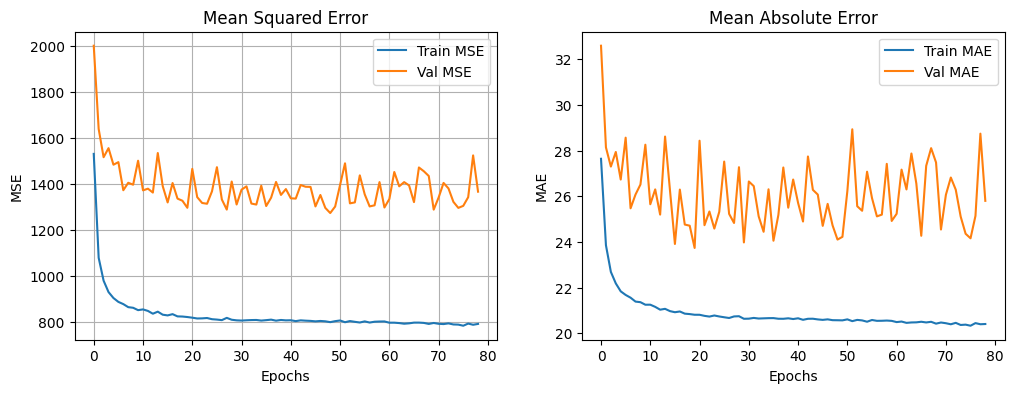

Validation Loss = 1273.3110
least val_loss = 1273.3110
16 nodes | dropout: 0 | lr: 0.01 | batch size: 64


c:\Users\Admin\anaconda3\envs\Sustain\lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  N-D tensor with shape: `(batch_size, ..., input_dim)`.


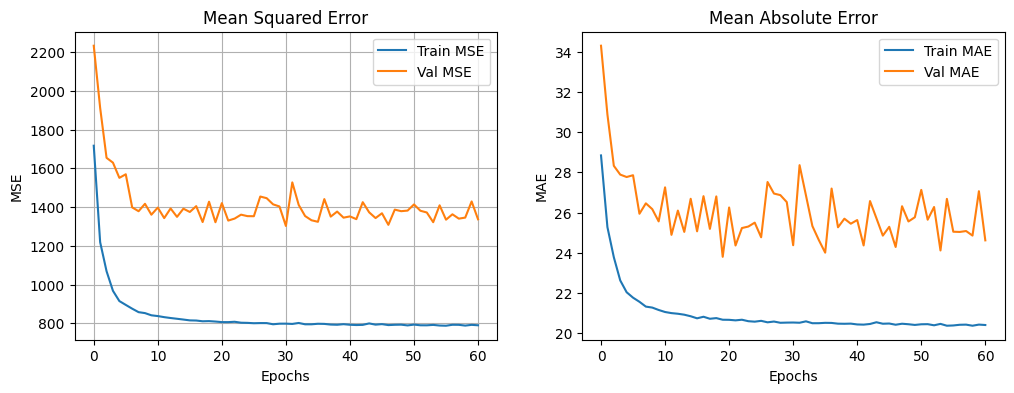

Validation Loss = 1302.6199
16 nodes | dropout: 0 | lr: 0.01 | batch size: 128


c:\Users\Admin\anaconda3\envs\Sustain\lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  N-D tensor with shape: `(batch_size, ..., input_dim)`.


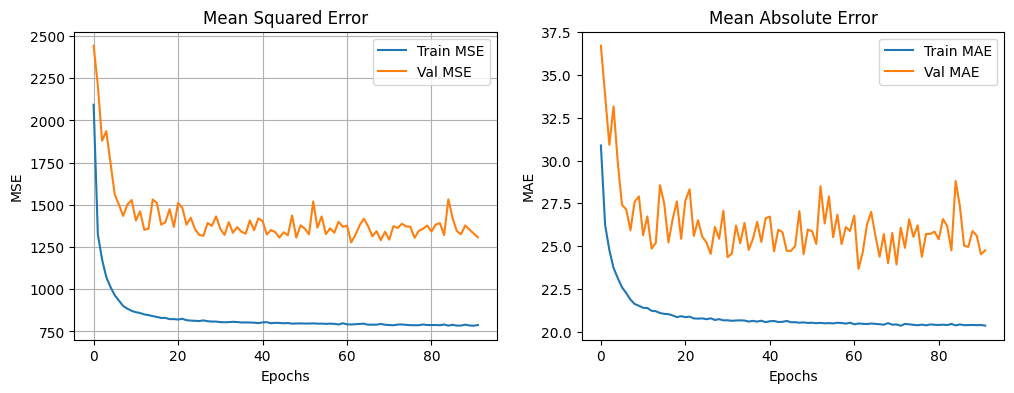

Validation Loss = 1277.3765
16 nodes | dropout: 0 | lr: 0.005 | batch size: 32


c:\Users\Admin\anaconda3\envs\Sustain\lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  N-D tensor with shape: `(batch_size, ..., input_dim)`.


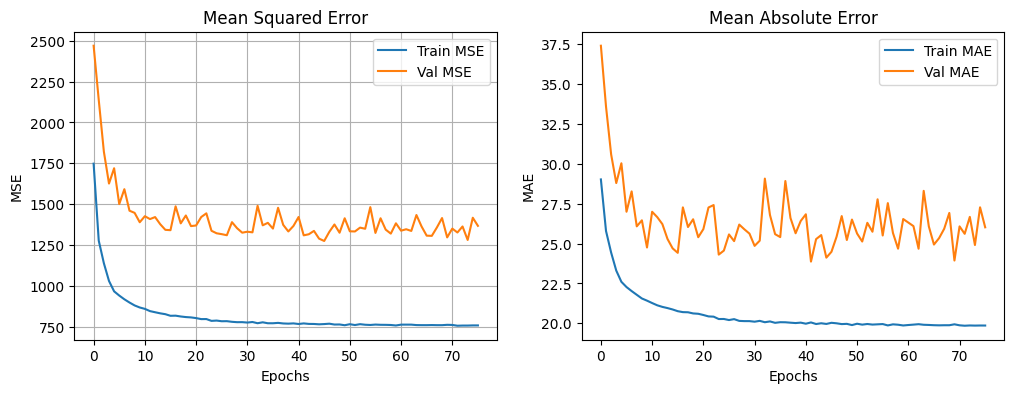

Validation Loss = 1274.1808
16 nodes | dropout: 0 | lr: 0.005 | batch size: 64


c:\Users\Admin\anaconda3\envs\Sustain\lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  N-D tensor with shape: `(batch_size, ..., input_dim)`.


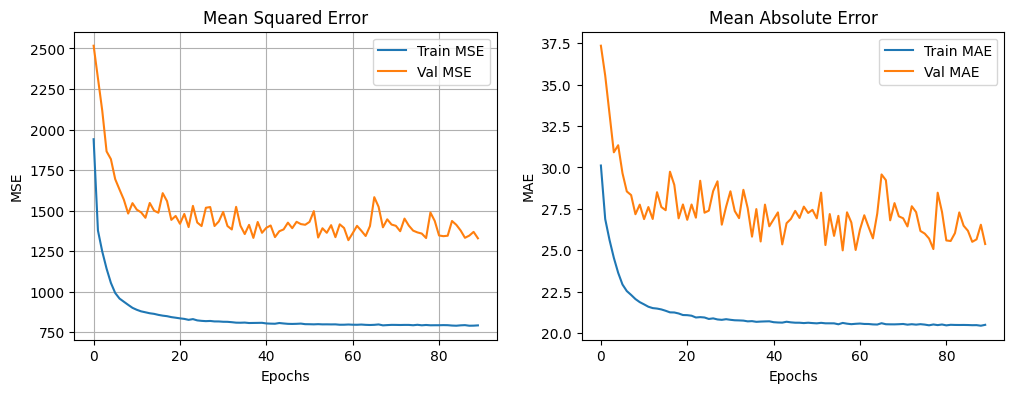

Validation Loss = 1317.7130
16 nodes | dropout: 0 | lr: 0.005 | batch size: 128


c:\Users\Admin\anaconda3\envs\Sustain\lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  N-D tensor with shape: `(batch_size, ..., input_dim)`.


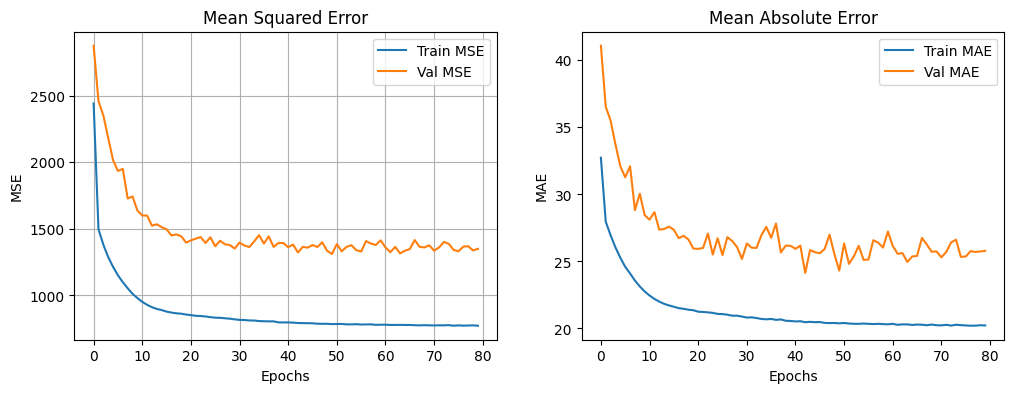

Validation Loss = 1311.1278
16 nodes | dropout: 0 | lr: 0.001 | batch size: 32


c:\Users\Admin\anaconda3\envs\Sustain\lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  N-D tensor with shape: `(batch_size, ..., input_dim)`.


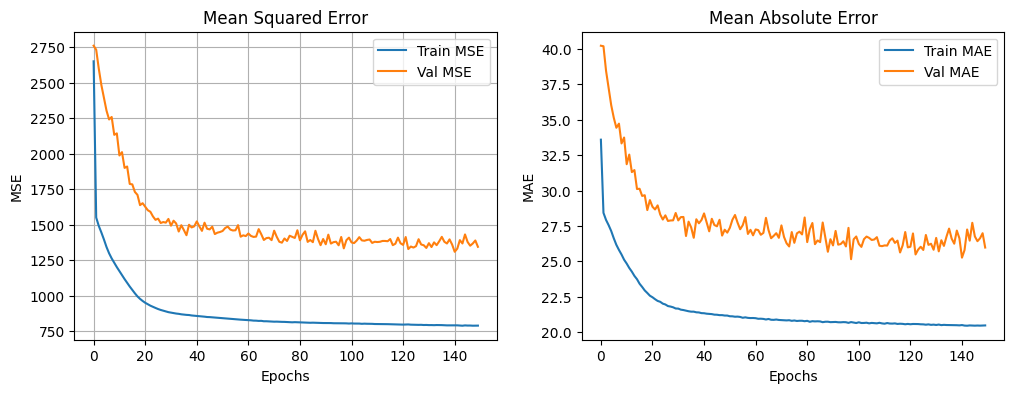

Validation Loss = 1344.0885
16 nodes | dropout: 0 | lr: 0.001 | batch size: 64


c:\Users\Admin\anaconda3\envs\Sustain\lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  N-D tensor with shape: `(batch_size, ..., input_dim)`.


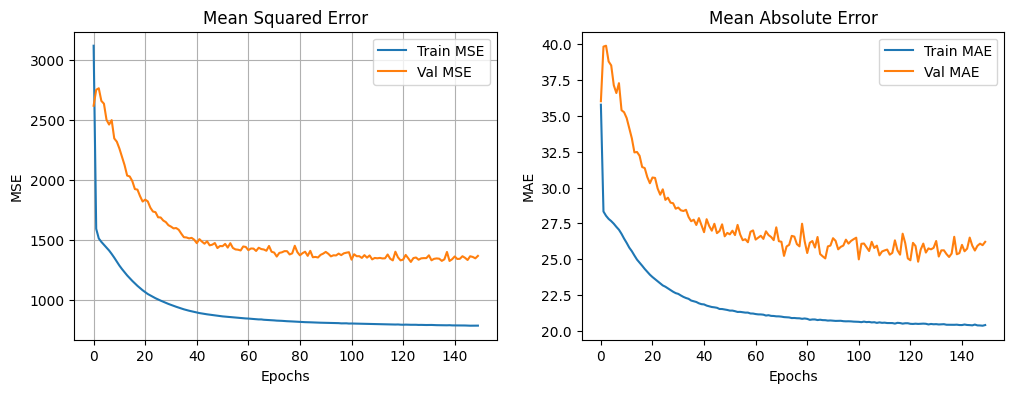

Validation Loss = 1365.9543
16 nodes | dropout: 0 | lr: 0.001 | batch size: 128


c:\Users\Admin\anaconda3\envs\Sustain\lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  N-D tensor with shape: `(batch_size, ..., input_dim)`.


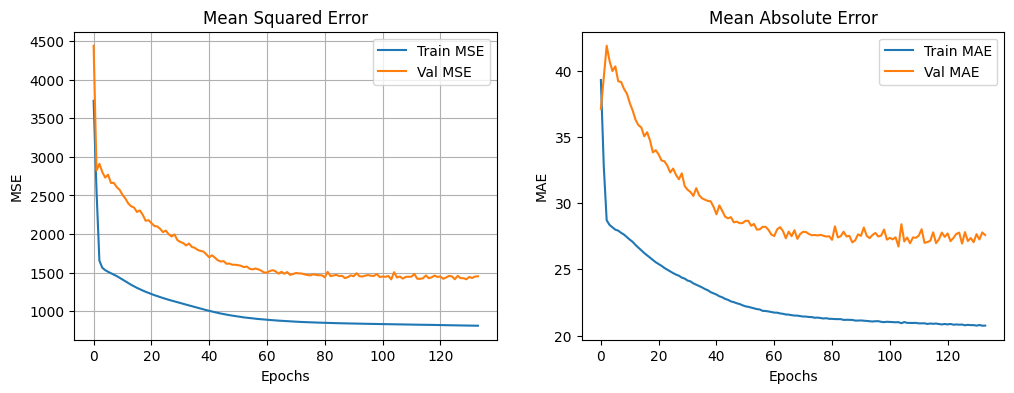

Validation Loss = 1412.1929
16 nodes | dropout: 0.2 | lr: 0.01 | batch size: 32


c:\Users\Admin\anaconda3\envs\Sustain\lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  N-D tensor with shape: `(batch_size, ..., input_dim)`.


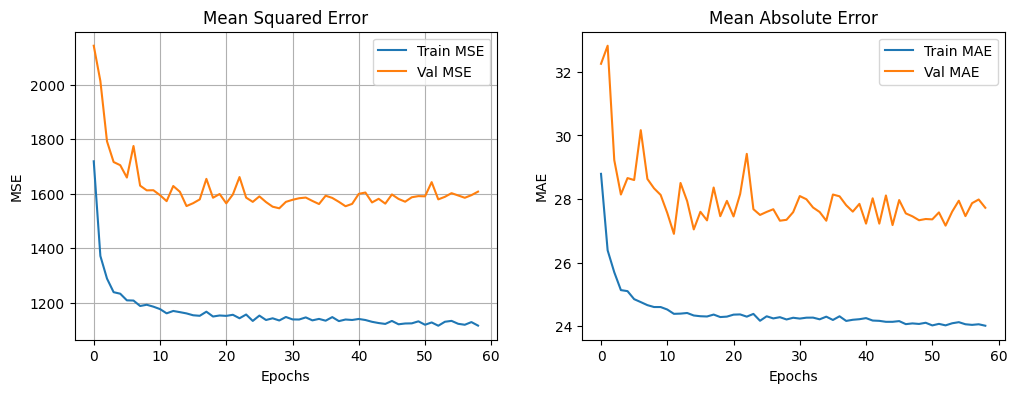

Validation Loss = 1546.4762
16 nodes | dropout: 0.2 | lr: 0.01 | batch size: 64


c:\Users\Admin\anaconda3\envs\Sustain\lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  N-D tensor with shape: `(batch_size, ..., input_dim)`.


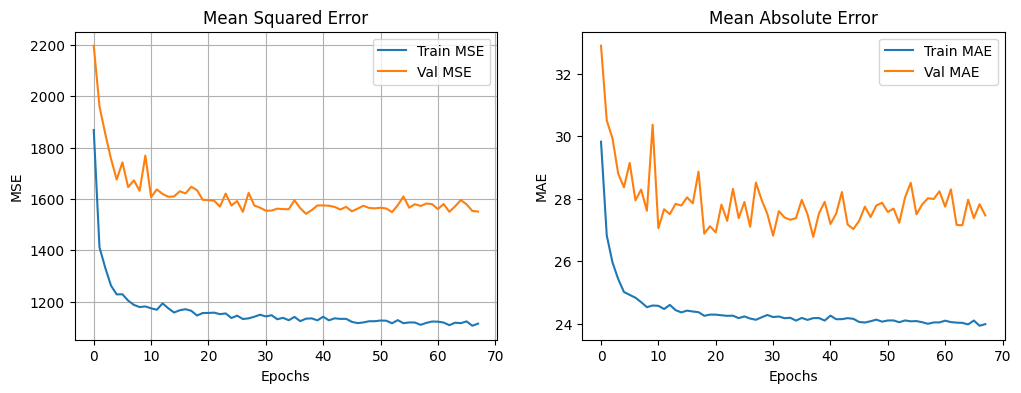

Validation Loss = 1541.6913
16 nodes | dropout: 0.2 | lr: 0.01 | batch size: 128


c:\Users\Admin\anaconda3\envs\Sustain\lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  N-D tensor with shape: `(batch_size, ..., input_dim)`.


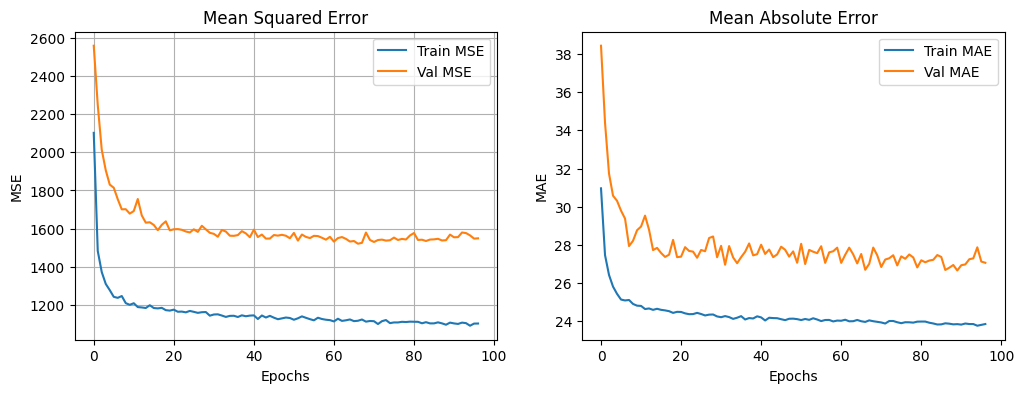

Validation Loss = 1520.7531
16 nodes | dropout: 0.2 | lr: 0.005 | batch size: 32


c:\Users\Admin\anaconda3\envs\Sustain\lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  N-D tensor with shape: `(batch_size, ..., input_dim)`.


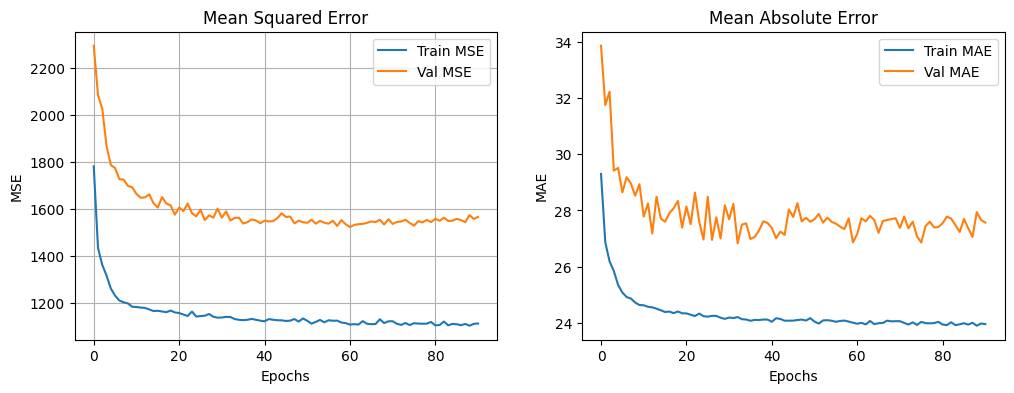

Validation Loss = 1522.5782
16 nodes | dropout: 0.2 | lr: 0.005 | batch size: 64


c:\Users\Admin\anaconda3\envs\Sustain\lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  N-D tensor with shape: `(batch_size, ..., input_dim)`.


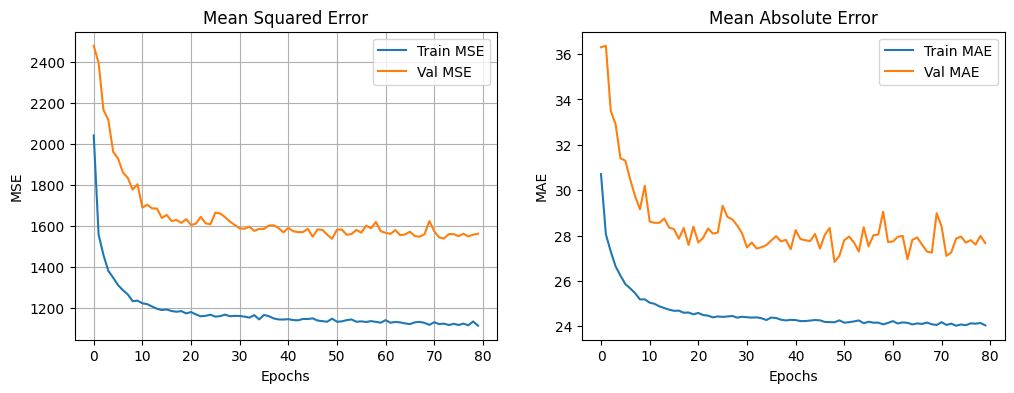

Validation Loss = 1537.2557
16 nodes | dropout: 0.2 | lr: 0.005 | batch size: 128


c:\Users\Admin\anaconda3\envs\Sustain\lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  N-D tensor with shape: `(batch_size, ..., input_dim)`.


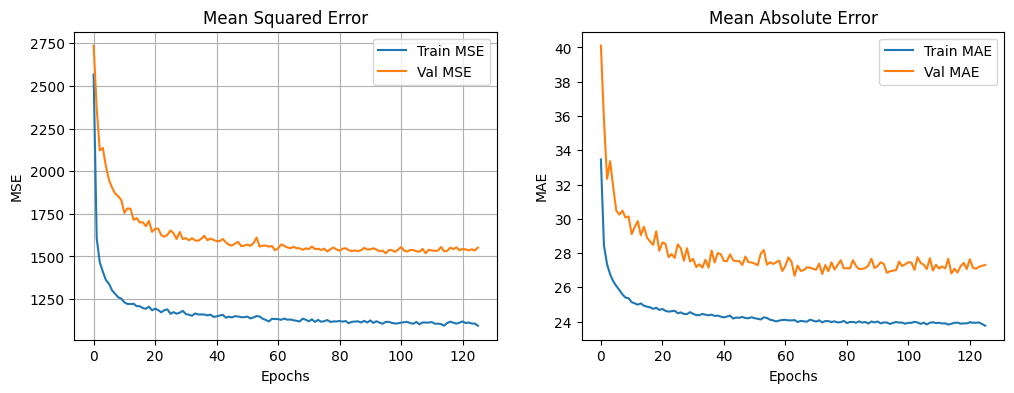

Validation Loss = 1518.7593
16 nodes | dropout: 0.2 | lr: 0.001 | batch size: 32


c:\Users\Admin\anaconda3\envs\Sustain\lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  N-D tensor with shape: `(batch_size, ..., input_dim)`.


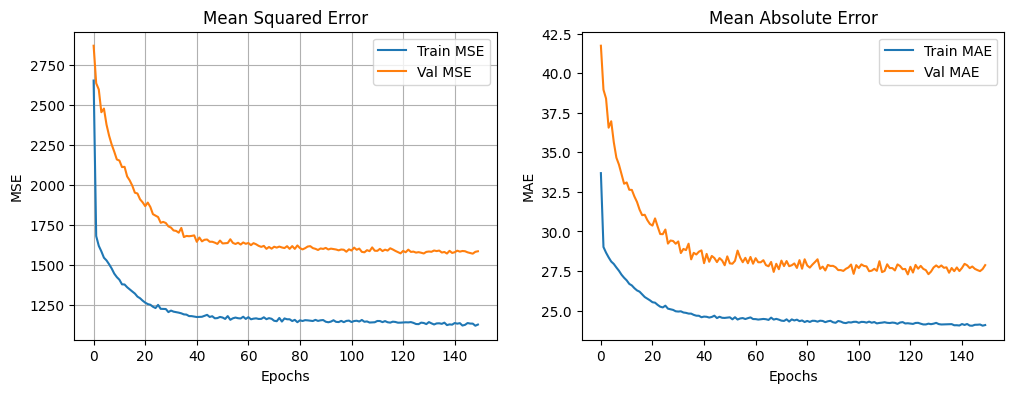

Validation Loss = 1585.5146
16 nodes | dropout: 0.2 | lr: 0.001 | batch size: 64


c:\Users\Admin\anaconda3\envs\Sustain\lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  N-D tensor with shape: `(batch_size, ..., input_dim)`.


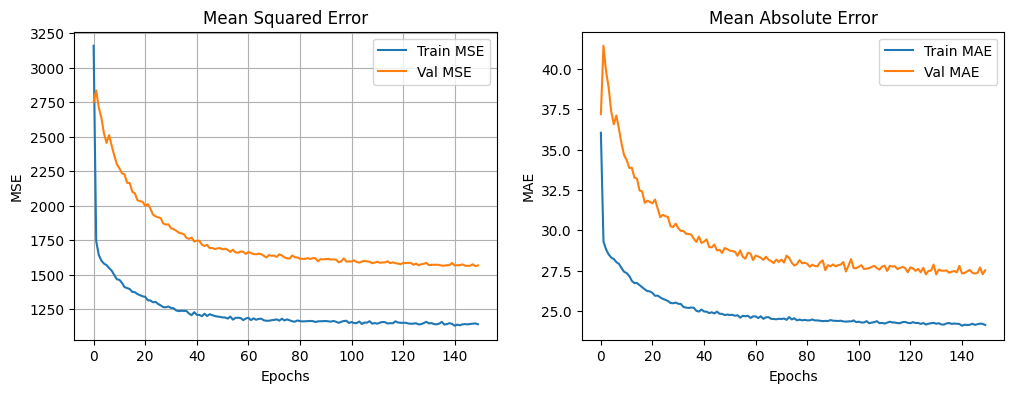

Validation Loss = 1565.6697
16 nodes | dropout: 0.2 | lr: 0.001 | batch size: 128


c:\Users\Admin\anaconda3\envs\Sustain\lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  N-D tensor with shape: `(batch_size, ..., input_dim)`.


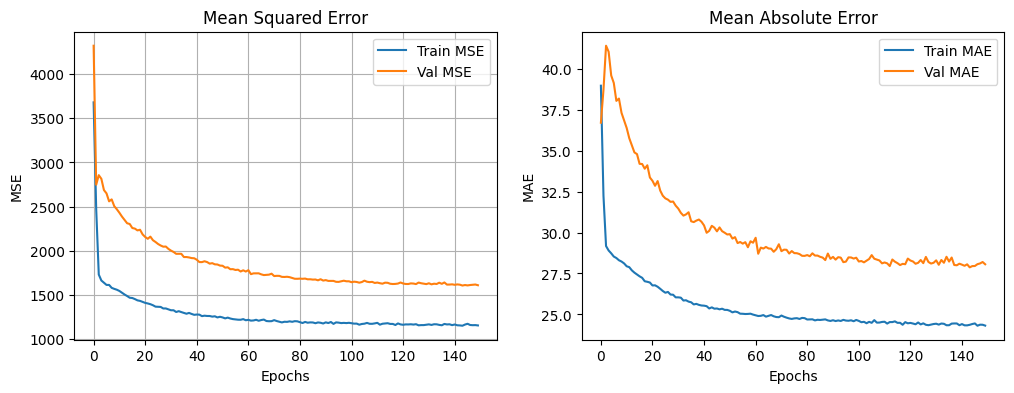

Validation Loss = 1606.7634
32 nodes | dropout: 0 | lr: 0.01 | batch size: 32


c:\Users\Admin\anaconda3\envs\Sustain\lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  N-D tensor with shape: `(batch_size, ..., input_dim)`.


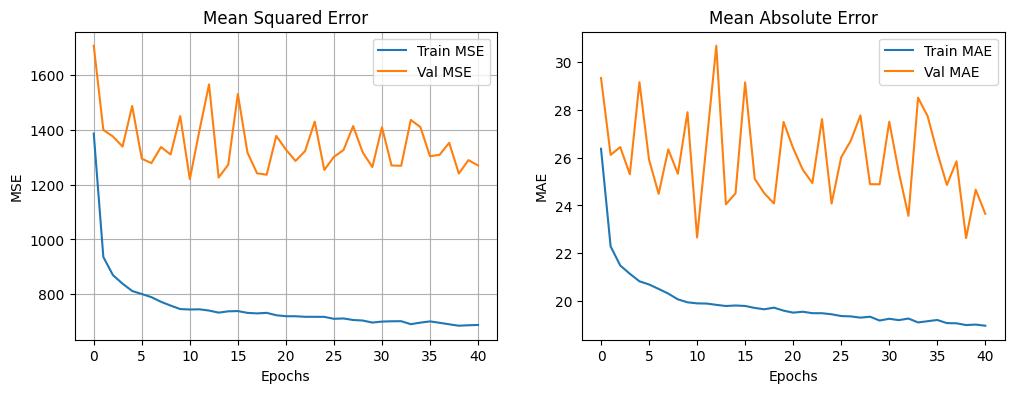

Validation Loss = 1220.0568
least val_loss = 1220.0568
32 nodes | dropout: 0 | lr: 0.01 | batch size: 64


c:\Users\Admin\anaconda3\envs\Sustain\lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  N-D tensor with shape: `(batch_size, ..., input_dim)`.


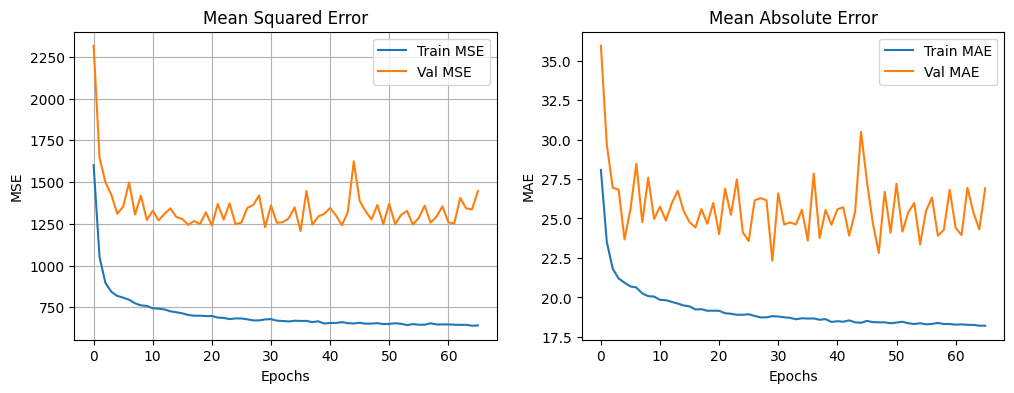

Validation Loss = 1206.1895
least val_loss = 1206.1895
32 nodes | dropout: 0 | lr: 0.01 | batch size: 128


c:\Users\Admin\anaconda3\envs\Sustain\lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  N-D tensor with shape: `(batch_size, ..., input_dim)`.


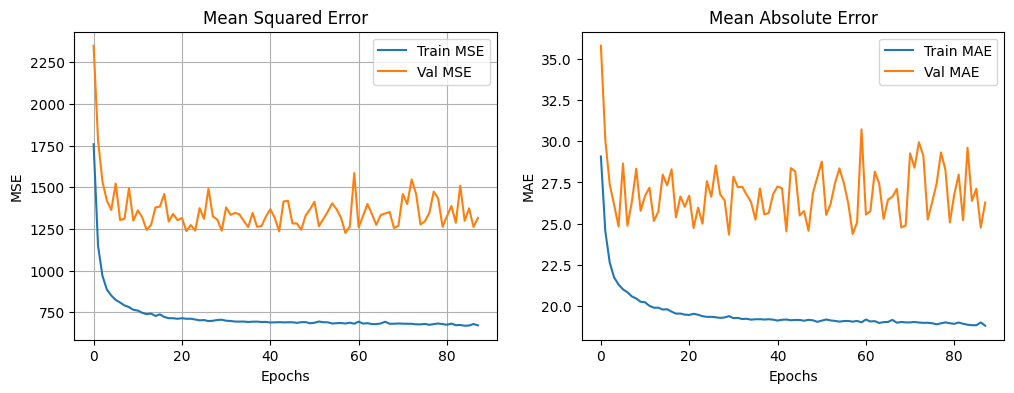

Validation Loss = 1226.0151
32 nodes | dropout: 0 | lr: 0.005 | batch size: 32


c:\Users\Admin\anaconda3\envs\Sustain\lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  N-D tensor with shape: `(batch_size, ..., input_dim)`.


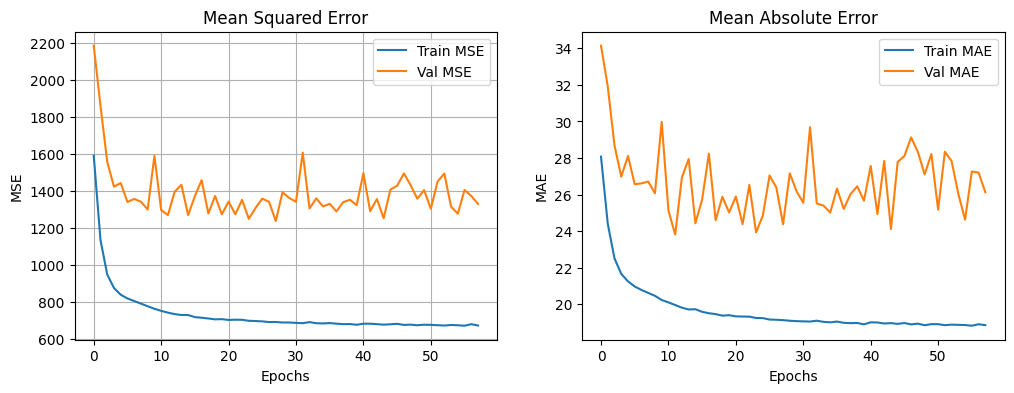

Validation Loss = 1238.5887
32 nodes | dropout: 0 | lr: 0.005 | batch size: 64


c:\Users\Admin\anaconda3\envs\Sustain\lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  N-D tensor with shape: `(batch_size, ..., input_dim)`.


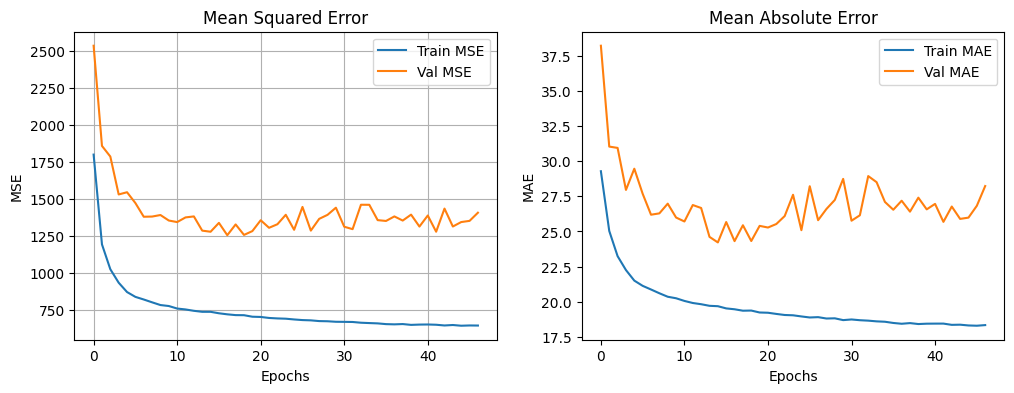

Validation Loss = 1254.1041
32 nodes | dropout: 0 | lr: 0.005 | batch size: 128


c:\Users\Admin\anaconda3\envs\Sustain\lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  N-D tensor with shape: `(batch_size, ..., input_dim)`.


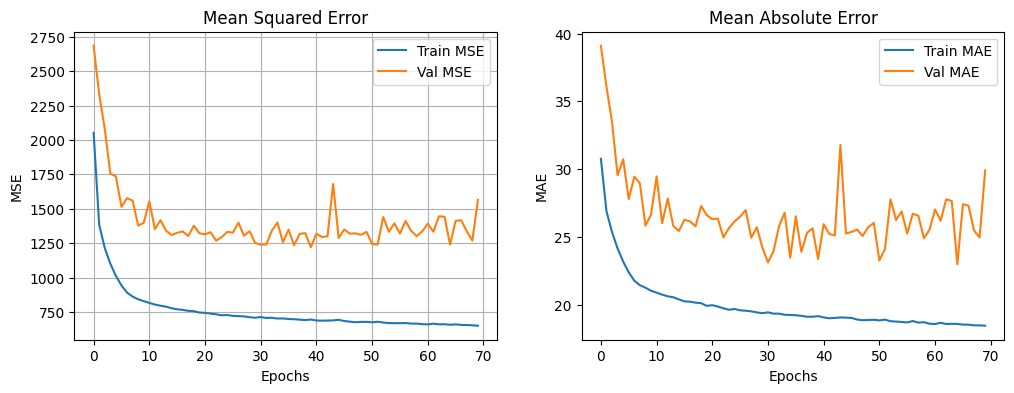

Validation Loss = 1220.4921
32 nodes | dropout: 0 | lr: 0.001 | batch size: 32


c:\Users\Admin\anaconda3\envs\Sustain\lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  N-D tensor with shape: `(batch_size, ..., input_dim)`.


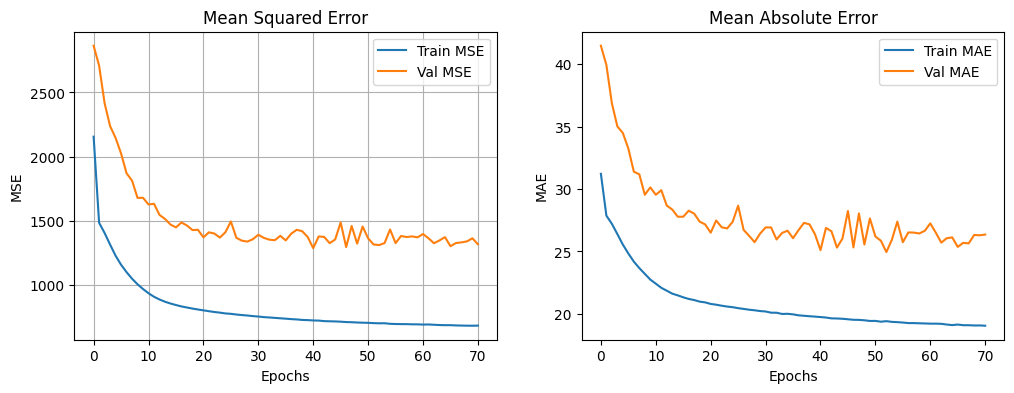

Validation Loss = 1289.3879
32 nodes | dropout: 0 | lr: 0.001 | batch size: 64


c:\Users\Admin\anaconda3\envs\Sustain\lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  N-D tensor with shape: `(batch_size, ..., input_dim)`.


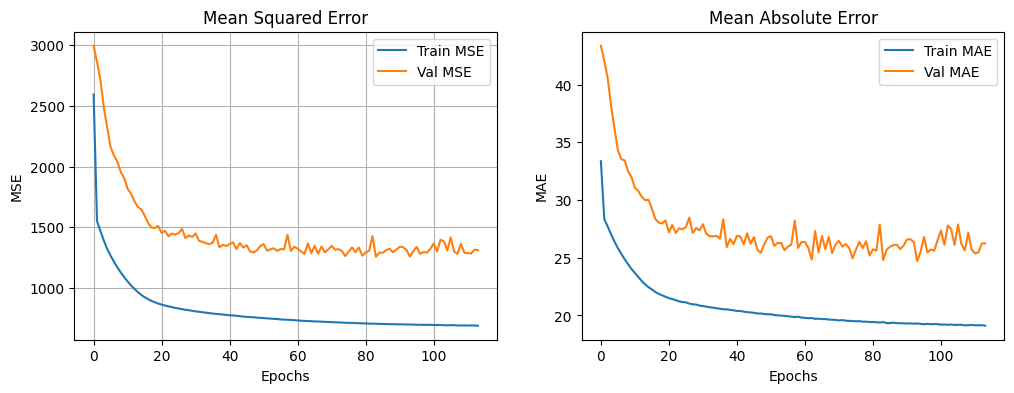

Validation Loss = 1254.8427
32 nodes | dropout: 0 | lr: 0.001 | batch size: 128


c:\Users\Admin\anaconda3\envs\Sustain\lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  N-D tensor with shape: `(batch_size, ..., input_dim)`.


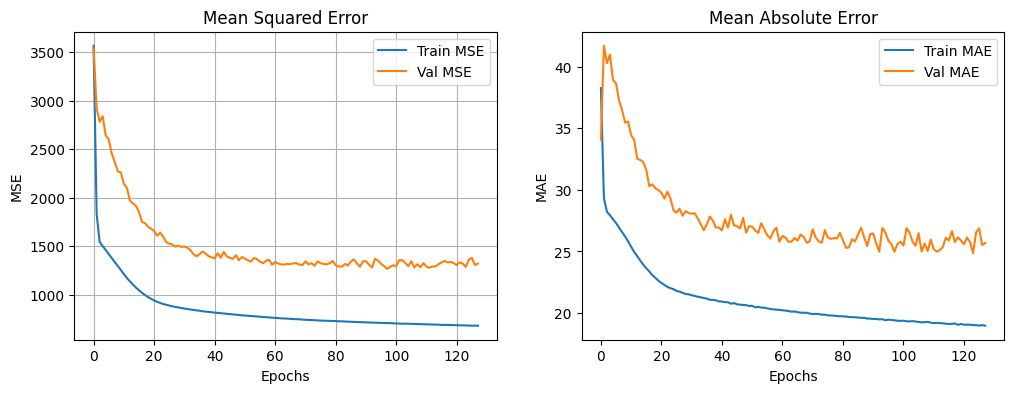

Validation Loss = 1266.4044
32 nodes | dropout: 0.2 | lr: 0.01 | batch size: 32


c:\Users\Admin\anaconda3\envs\Sustain\lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  N-D tensor with shape: `(batch_size, ..., input_dim)`.


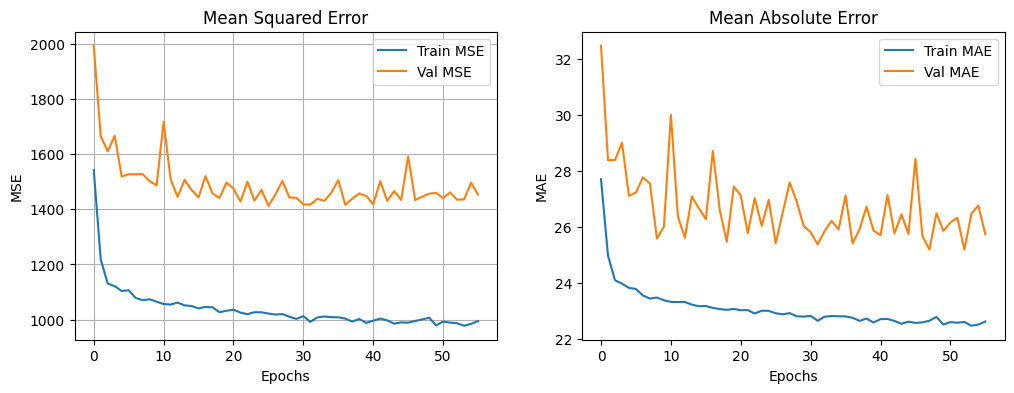

Validation Loss = 1412.5521
32 nodes | dropout: 0.2 | lr: 0.01 | batch size: 64


c:\Users\Admin\anaconda3\envs\Sustain\lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  N-D tensor with shape: `(batch_size, ..., input_dim)`.


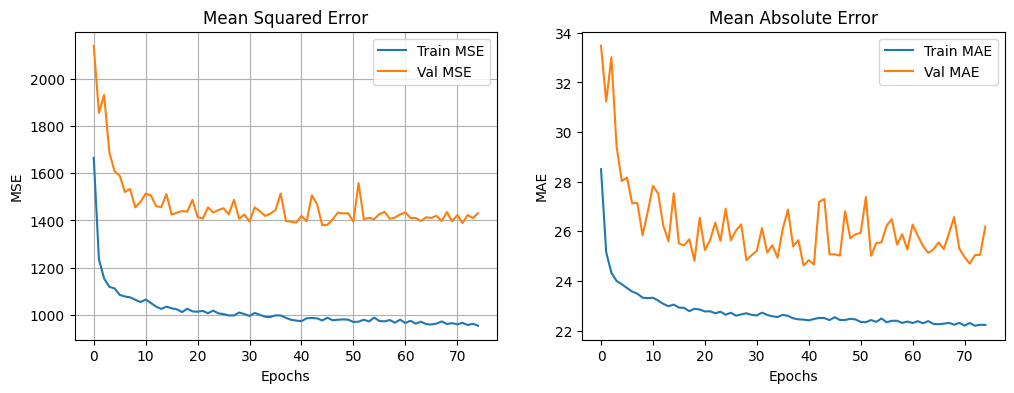

Validation Loss = 1379.7866
32 nodes | dropout: 0.2 | lr: 0.01 | batch size: 128


c:\Users\Admin\anaconda3\envs\Sustain\lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  N-D tensor with shape: `(batch_size, ..., input_dim)`.


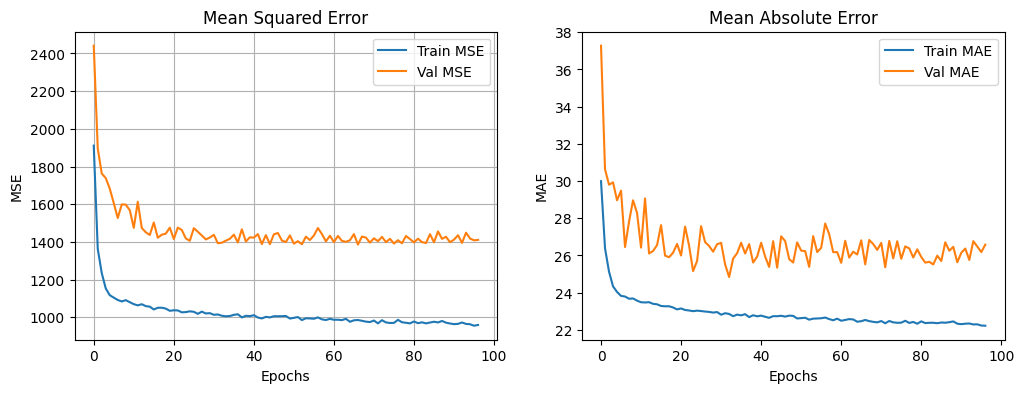

Validation Loss = 1385.5776
32 nodes | dropout: 0.2 | lr: 0.005 | batch size: 32


c:\Users\Admin\anaconda3\envs\Sustain\lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  N-D tensor with shape: `(batch_size, ..., input_dim)`.


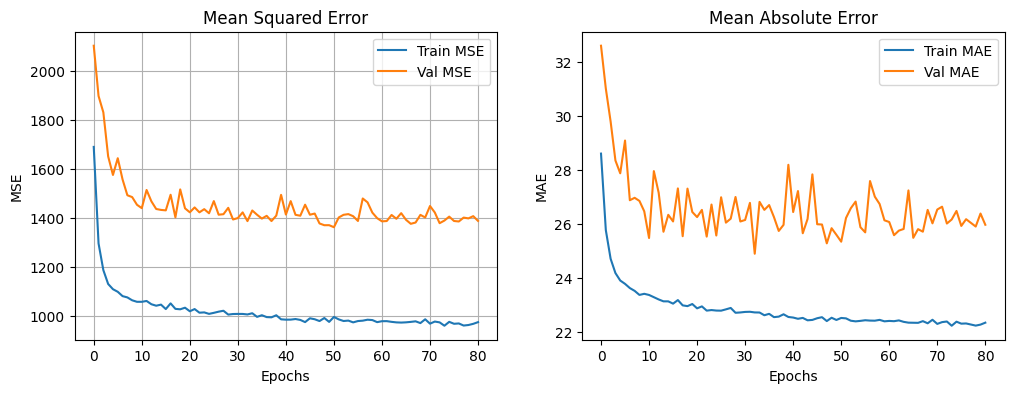

Validation Loss = 1361.7064
32 nodes | dropout: 0.2 | lr: 0.005 | batch size: 64


c:\Users\Admin\anaconda3\envs\Sustain\lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  N-D tensor with shape: `(batch_size, ..., input_dim)`.


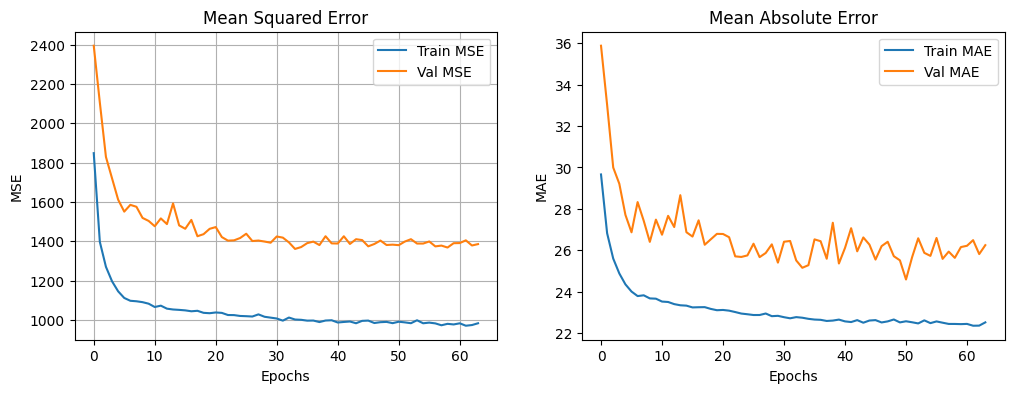

Validation Loss = 1361.0388
32 nodes | dropout: 0.2 | lr: 0.005 | batch size: 128


c:\Users\Admin\anaconda3\envs\Sustain\lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  N-D tensor with shape: `(batch_size, ..., input_dim)`.


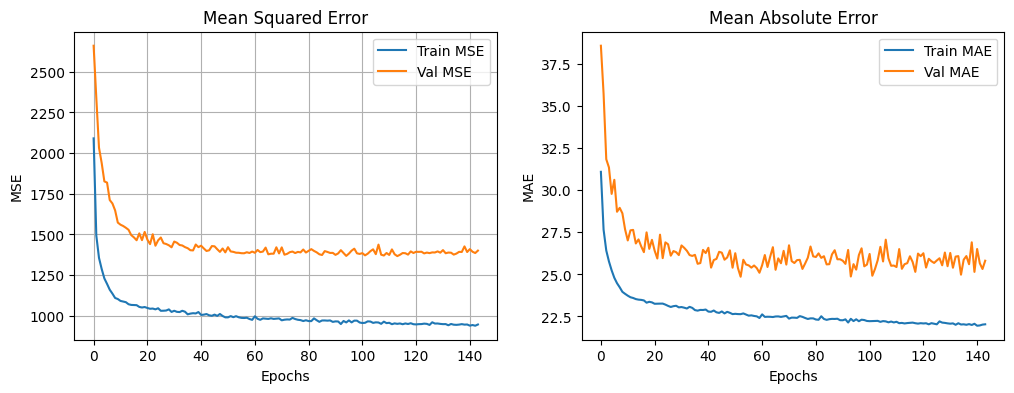

Validation Loss = 1367.1432
32 nodes | dropout: 0.2 | lr: 0.001 | batch size: 32


c:\Users\Admin\anaconda3\envs\Sustain\lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  N-D tensor with shape: `(batch_size, ..., input_dim)`.


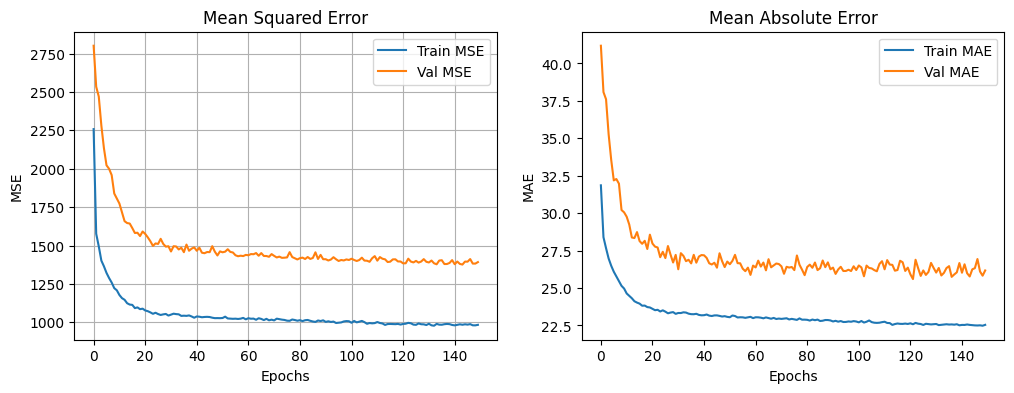

Validation Loss = 1392.2540
32 nodes | dropout: 0.2 | lr: 0.001 | batch size: 64


c:\Users\Admin\anaconda3\envs\Sustain\lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  N-D tensor with shape: `(batch_size, ..., input_dim)`.


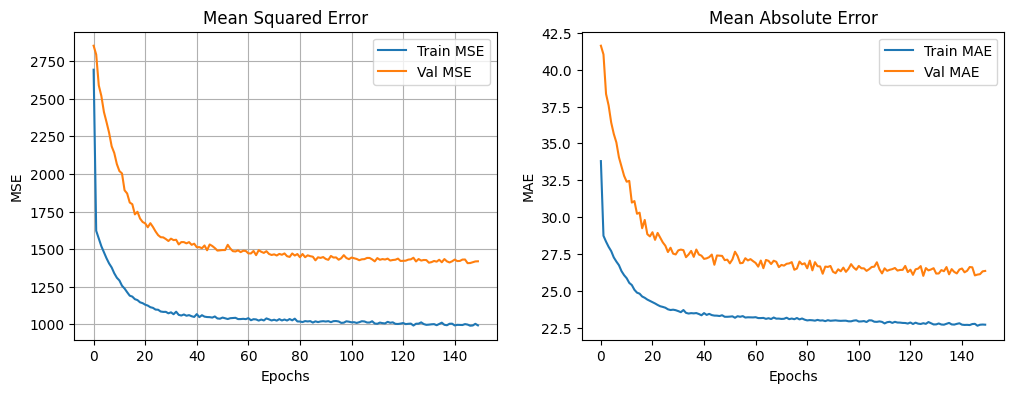

Validation Loss = 1419.3531
32 nodes | dropout: 0.2 | lr: 0.001 | batch size: 128


c:\Users\Admin\anaconda3\envs\Sustain\lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  N-D tensor with shape: `(batch_size, ..., input_dim)`.


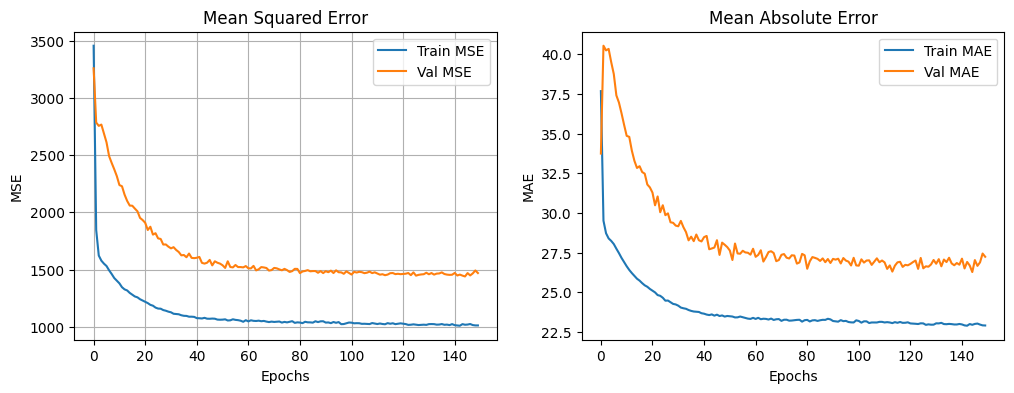

Validation Loss = 1469.4624
64 nodes | dropout: 0 | lr: 0.01 | batch size: 32


c:\Users\Admin\anaconda3\envs\Sustain\lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  N-D tensor with shape: `(batch_size, ..., input_dim)`.


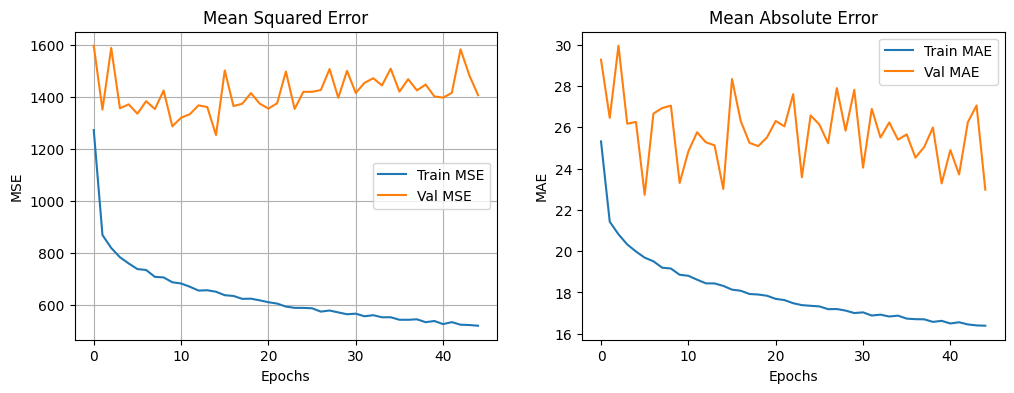

Validation Loss = 1252.4331
64 nodes | dropout: 0 | lr: 0.01 | batch size: 64


c:\Users\Admin\anaconda3\envs\Sustain\lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  N-D tensor with shape: `(batch_size, ..., input_dim)`.


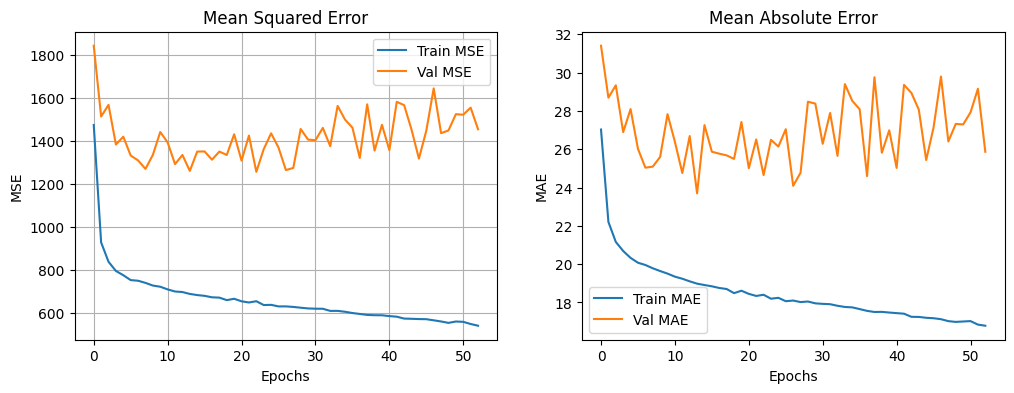

Validation Loss = 1256.6239
64 nodes | dropout: 0 | lr: 0.01 | batch size: 128


c:\Users\Admin\anaconda3\envs\Sustain\lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  N-D tensor with shape: `(batch_size, ..., input_dim)`.


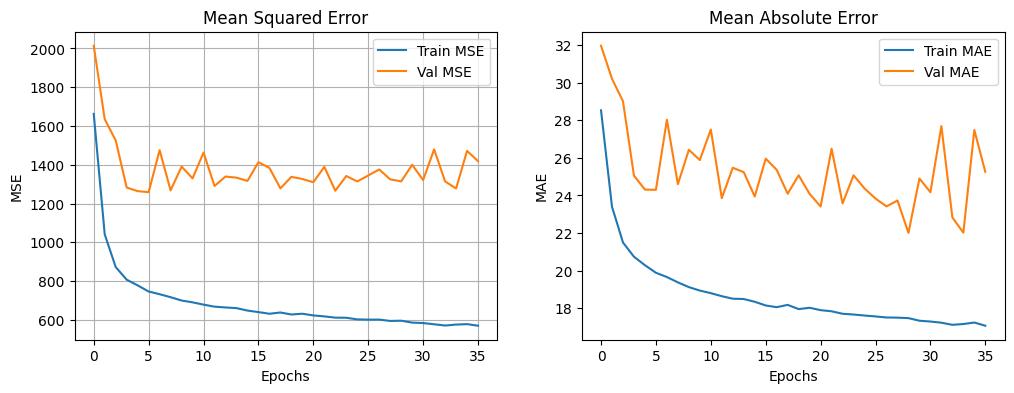

Validation Loss = 1258.6337
64 nodes | dropout: 0 | lr: 0.005 | batch size: 32


c:\Users\Admin\anaconda3\envs\Sustain\lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  N-D tensor with shape: `(batch_size, ..., input_dim)`.


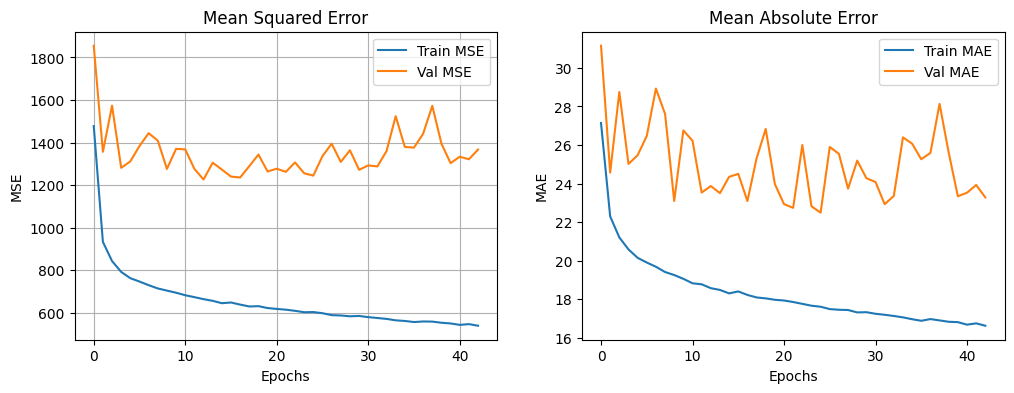

Validation Loss = 1226.5990
64 nodes | dropout: 0 | lr: 0.005 | batch size: 64


c:\Users\Admin\anaconda3\envs\Sustain\lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  N-D tensor with shape: `(batch_size, ..., input_dim)`.


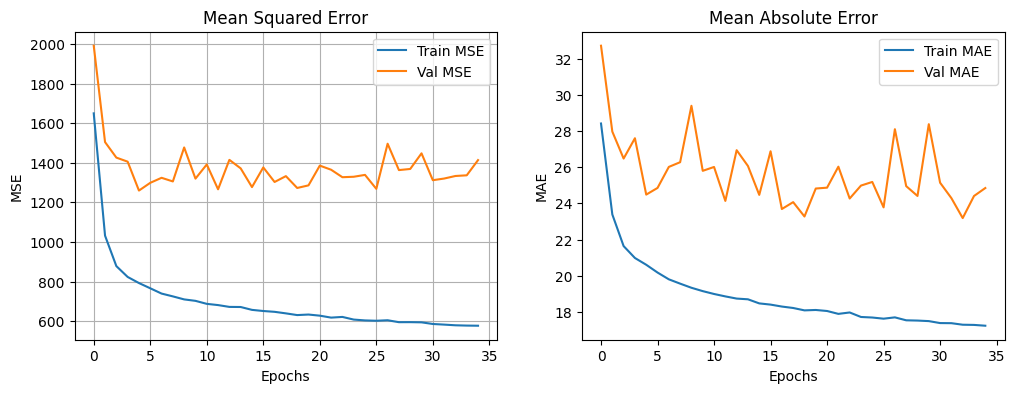

Validation Loss = 1259.6042
64 nodes | dropout: 0 | lr: 0.005 | batch size: 128


c:\Users\Admin\anaconda3\envs\Sustain\lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  N-D tensor with shape: `(batch_size, ..., input_dim)`.


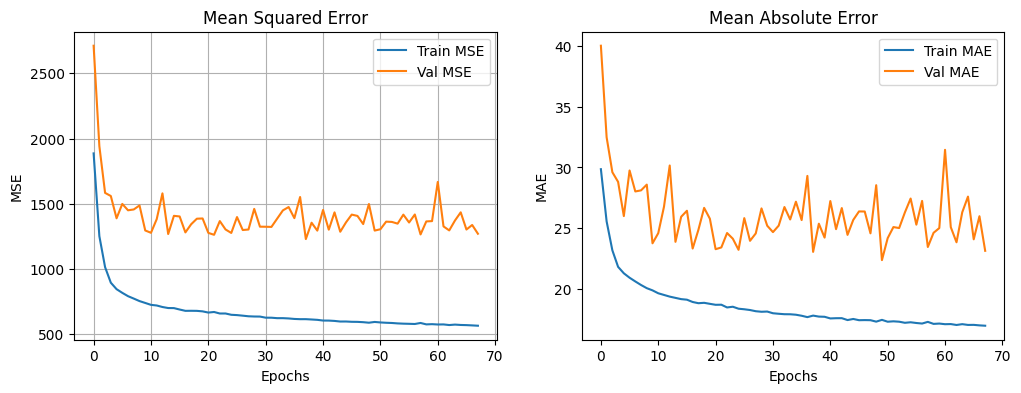

Validation Loss = 1228.2230
64 nodes | dropout: 0 | lr: 0.001 | batch size: 32


c:\Users\Admin\anaconda3\envs\Sustain\lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  N-D tensor with shape: `(batch_size, ..., input_dim)`.


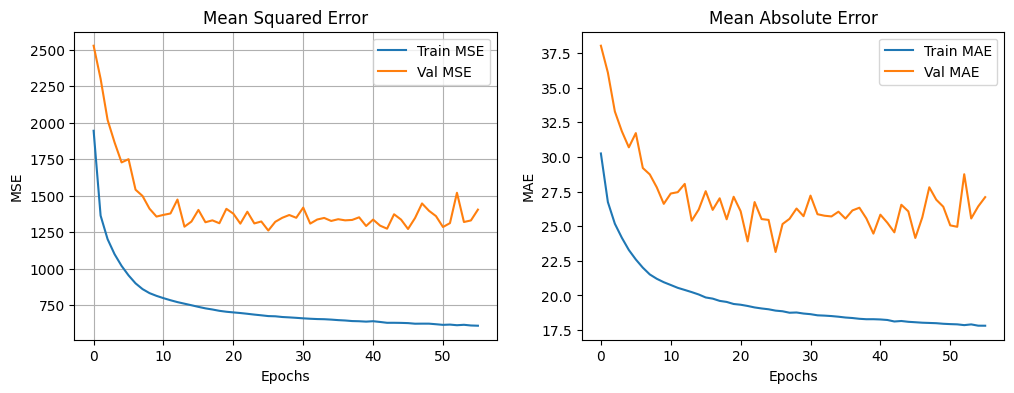

Validation Loss = 1260.5637
64 nodes | dropout: 0 | lr: 0.001 | batch size: 64


c:\Users\Admin\anaconda3\envs\Sustain\lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  N-D tensor with shape: `(batch_size, ..., input_dim)`.


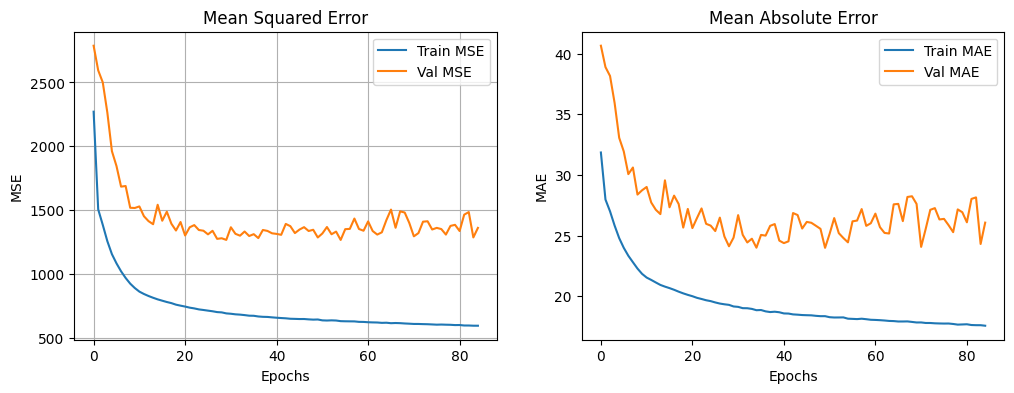

Validation Loss = 1265.5707
64 nodes | dropout: 0 | lr: 0.001 | batch size: 128


c:\Users\Admin\anaconda3\envs\Sustain\lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  N-D tensor with shape: `(batch_size, ..., input_dim)`.


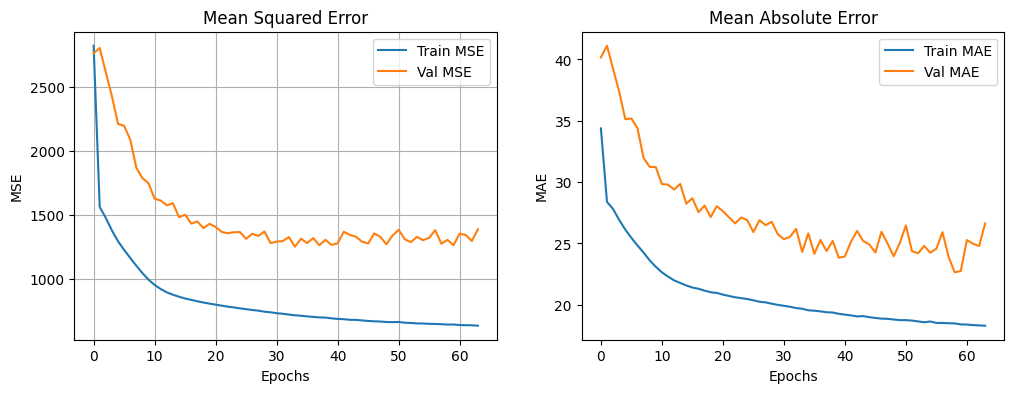

Validation Loss = 1255.6261
64 nodes | dropout: 0.2 | lr: 0.01 | batch size: 32


c:\Users\Admin\anaconda3\envs\Sustain\lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  N-D tensor with shape: `(batch_size, ..., input_dim)`.


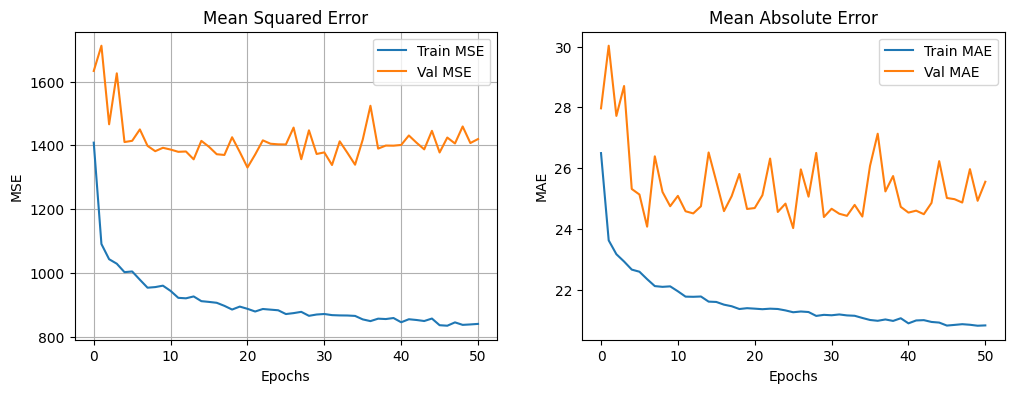

Validation Loss = 1330.6381
64 nodes | dropout: 0.2 | lr: 0.01 | batch size: 64


c:\Users\Admin\anaconda3\envs\Sustain\lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  N-D tensor with shape: `(batch_size, ..., input_dim)`.


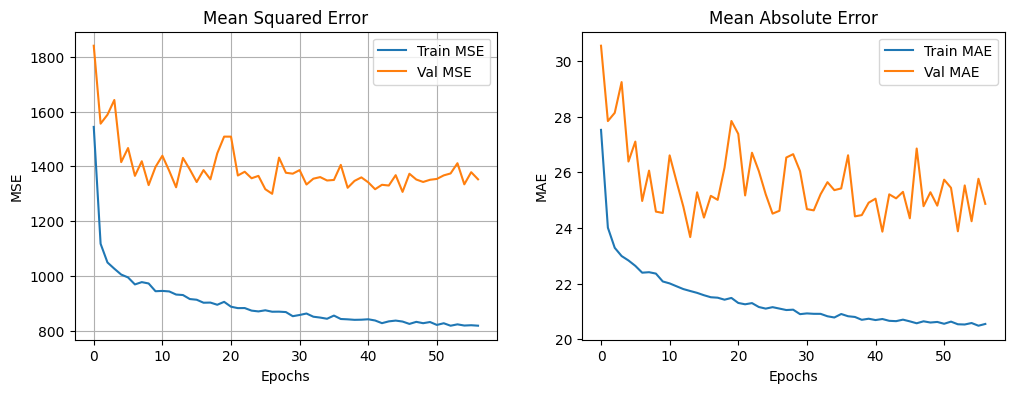

Validation Loss = 1299.5703
64 nodes | dropout: 0.2 | lr: 0.01 | batch size: 128


c:\Users\Admin\anaconda3\envs\Sustain\lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  N-D tensor with shape: `(batch_size, ..., input_dim)`.


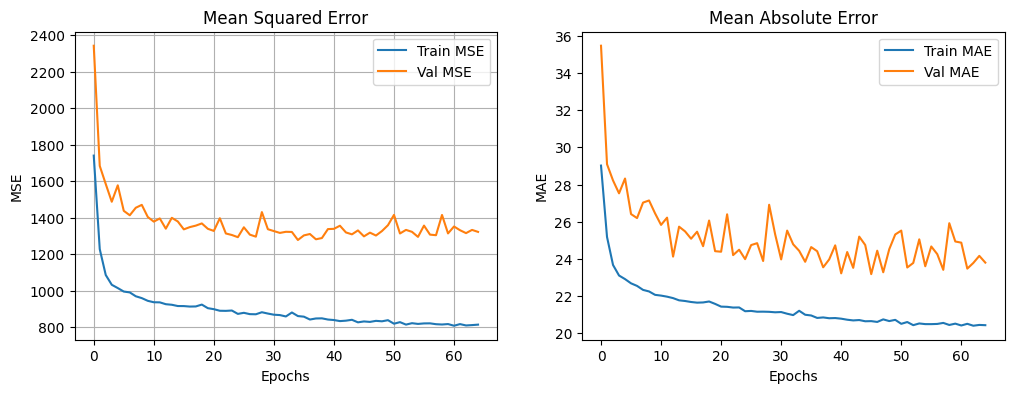

Validation Loss = 1277.9410
64 nodes | dropout: 0.2 | lr: 0.005 | batch size: 32


c:\Users\Admin\anaconda3\envs\Sustain\lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  N-D tensor with shape: `(batch_size, ..., input_dim)`.


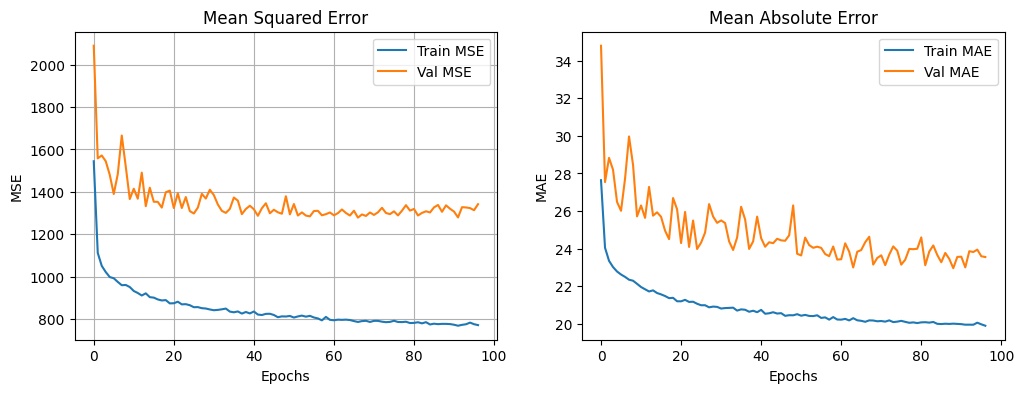

Validation Loss = 1278.7084
64 nodes | dropout: 0.2 | lr: 0.005 | batch size: 64


c:\Users\Admin\anaconda3\envs\Sustain\lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  N-D tensor with shape: `(batch_size, ..., input_dim)`.


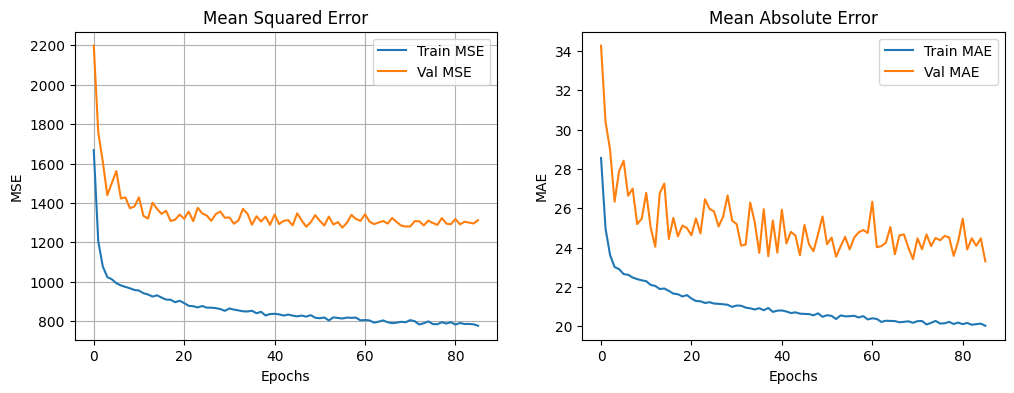

Validation Loss = 1274.6799
64 nodes | dropout: 0.2 | lr: 0.005 | batch size: 128


c:\Users\Admin\anaconda3\envs\Sustain\lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  N-D tensor with shape: `(batch_size, ..., input_dim)`.


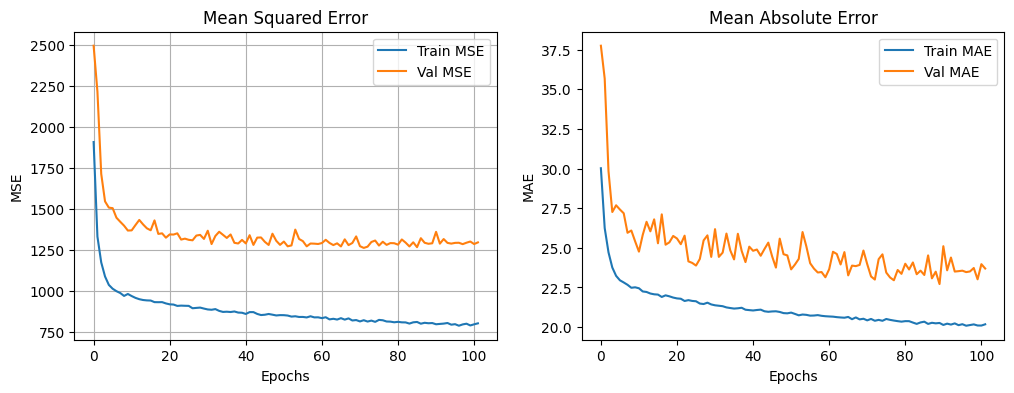

Validation Loss = 1260.8304
64 nodes | dropout: 0.2 | lr: 0.001 | batch size: 32


c:\Users\Admin\anaconda3\envs\Sustain\lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  N-D tensor with shape: `(batch_size, ..., input_dim)`.


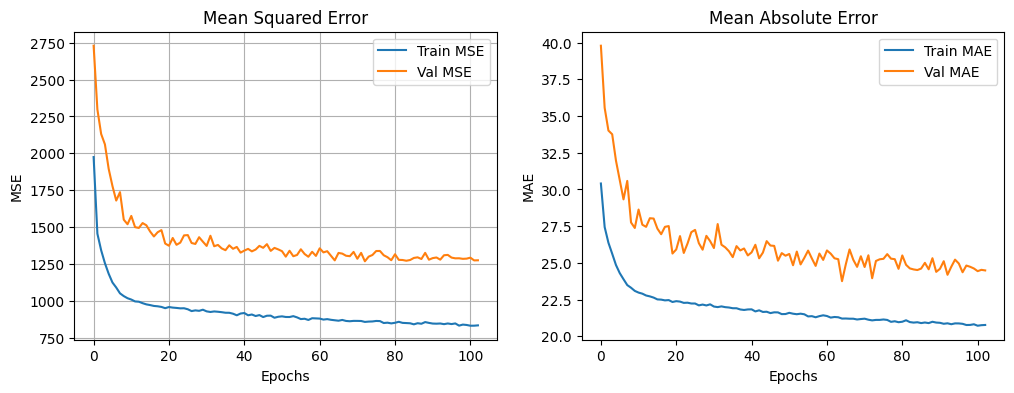

Validation Loss = 1269.0188
64 nodes | dropout: 0.2 | lr: 0.001 | batch size: 64


c:\Users\Admin\anaconda3\envs\Sustain\lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  N-D tensor with shape: `(batch_size, ..., input_dim)`.


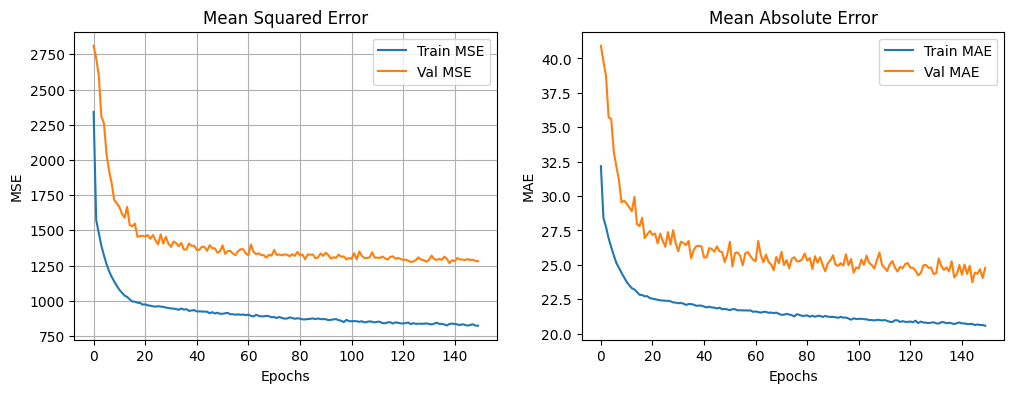

Validation Loss = 1281.3676
64 nodes | dropout: 0.2 | lr: 0.001 | batch size: 128


c:\Users\Admin\anaconda3\envs\Sustain\lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  N-D tensor with shape: `(batch_size, ..., input_dim)`.


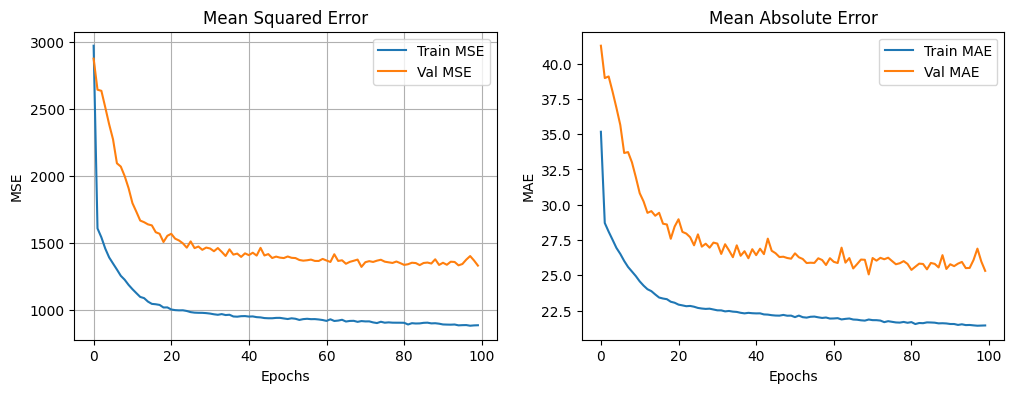

Validation Loss = 1320.3564


In [564]:
least_val_loss = float('inf')
least_loss_model = None
epochs = 150  

for num_nodes in [16, 32, 64]:
    for dropout_prob in [0, 0.2]:
        for lr in [0.01, 0.005, 0.001]:
            for batch_size in [32, 64, 128]:
                print(f"{num_nodes} nodes | dropout: {dropout_prob} | lr: {lr} | batch size: {batch_size}")
                model, history = train_model(
                    x_train, y_train,
                    x_valid, y_valid,
                    num_nodes, dropout_prob, lr, batch_size, epochs
                )

                plot_history(history)
                val_loss = model.evaluate(x_valid, y_valid, verbose=0)[0]
                print(f"Validation Loss = {val_loss:.4f}")

                if val_loss < least_val_loss:
                    least_val_loss = val_loss
                    least_loss_model = model
                    print(f"least val_loss = {least_val_loss:.4f}")

In [569]:
print(least_loss_model) 
print(least_val_loss)

<Sequential name=sequential_83, built=True>
1206.189453125


In [567]:
# Use the best model found during the search
y_pred_nn_test = least_loss_model.predict(x_test)

# Calculate metrics
from sklearn.metrics import mean_squared_error, r2_score
rmse = np.sqrt(mean_squared_error(y_test, y_pred_nn_test))
r2 = r2_score(y_test, y_pred_nn_test)

print(f"Final NN Test RMSE: {rmse:.4f}")
print(f"Final NN Test R²: {r2:.4f}")

121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 928us/step
Final NN Test RMSE: 25.6530
Final NN Test R²: 0.5810


In [571]:
y_test

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23
29447,39.0,38.0,38.0,37.0,28.0,30.0,27.0,19.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,35.0,5.0,23.0,12.0,68.0,80.0,65.0,25.0,31.0
29451,27.0,26.0,26.0,26.0,26.0,26.0,26.0,3.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,4.0,39.0,57.0,18.0,17.0,31.0,51.0,41.0
29457,40.0,40.0,36.0,30.0,29.0,30.0,29.0,30.0,7.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,23.0,9.0,0.0,0.0,6.0,11.0,0.0
29468,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,11.0,21.0,18.0,12.0,10.0,0.0,0.0,17.0,45.0,25.0,6.0,0.0,0.0
29462,16.0,10.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,14.0,27.0,27.0,22.0,15.0,12.0,13.0,4.0,0.0,0.0,1.0,16.0,26.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29438,27.0,35.0,31.0,29.0,29.0,30.0,29.0,29.0,29.0,28.0,28.0,17.0,29.0,0.0,0.0,0.0,0.0,3.0,20.0,0.0,0.0,0.0,0.0,10.0
29439,44.0,36.0,31.0,32.0,33.0,32.0,32.0,31.0,31.0,3.0,6.0,0.0,0.0,0.0,8.0,12.0,4.0,0.0,0.0,1.0,0.0,0.0,31.0,31.0
29440,24.0,35.0,49.0,29.0,26.0,26.0,25.0,26.0,25.0,6.0,0.0,0.0,26.0,0.0,0.0,0.0,0.0,37.0,29.0,27.0,26.0,20.0,19.0,101.0
29441,54.0,38.0,26.0,27.0,27.0,26.0,27.0,27.0,27.0,26.0,29.0,0.0,0.0,0.0,21.0,8.0,29.0,34.0,31.0,37.0,28.0,58.0,28.0,0.0


In [570]:
y_pred_nn_test

array([[ 45.249546,  46.911903,  44.18041 , ...,  79.892784,  33.939575,
         34.041836],
       [ 37.312916,  29.436258,  25.477486, ...,  43.241158,  56.691677,
         43.44892 ],
       [ 57.002003,  42.434093,  33.62464 , ...,  20.18527 ,  14.765761,
         18.6641  ],
       ...,
       [ 25.516497,  34.61459 ,  47.239216, ...,  29.289772,  22.045078,
        102.504486],
       [ 65.997635,  49.468876,  38.313965, ...,  81.66935 ,  46.14748 ,
         10.305286],
       [ 26.007355,  80.48402 ,  61.78358 , ...,  36.873203,  32.943577,
         28.36702 ]], shape=(3848, 24), dtype=float32)